In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycaret as py

In [2]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [4]:
from pycaret.classification import *
exp = setup(data,target='Outcome',train_size=0.8,normalize=True,normalize_method='minmax',
    fix_imbalance=True,fix_imbalance_method='SMOTE')

,Description,Value
0,Session id,162
1,Target,Outcome
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(954, 9)"
5,Transformed train set shape,"(800, 9)"
6,Transformed test set shape,"(154, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [5]:
get_config('y_transformed').value_counts()

Outcome
0    500
1    454
Name: count, dtype: int64

In [6]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7590,0.8045,0.7136,0.6501,0.6740,0.4848,0.4921,0.0680
rf,Random Forest Classifier,0.7540,0.8060,0.6716,0.6438,0.6529,0.4632,0.4672,0.0800
catboost,CatBoost Classifier,0.7491,0.8033,0.6903,0.6325,0.6566,0.4601,0.4645,1.4510
nb,Naive Bayes,0.7459,0.8032,0.6766,0.6310,0.6492,0.4511,0.4554,0.0140
ridge,Ridge Classifier,0.7459,0.8161,0.7141,0.6243,0.6629,0.4614,0.4671,0.0140
lightgbm,Light Gradient Boosting Machine,0.7428,0.7768,0.6299,0.6363,0.6283,0.4323,0.4362,0.1130
et,Extra Trees Classifier,0.7409,0.8070,0.6481,0.6303,0.6348,0.4348,0.4384,0.0770
lr,Logistic Regression,0.7378,0.8126,0.6957,0.6154,0.6490,0.4420,0.4477,0.9900
lda,Linear Discriminant Analysis,0.7345,0.8124,0.7045,0.6109,0.6496,0.4390,0.4462,0.0130
ada,Ada Boost Classifier,0.7312,0.7968,0.6812,0.6113,0.6374,0.4262,0.4340,0.0480


GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=162, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [7]:
best = create_model('nb')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7581,0.8261,0.6818,0.6522,0.6667,0.4769,0.4772
1,0.7258,0.7602,0.6364,0.6087,0.6222,0.4072,0.4074
2,0.7097,0.8011,0.8182,0.5625,0.6667,0.4247,0.4482
3,0.7742,0.8511,0.7273,0.6667,0.6957,0.5167,0.5179
4,0.7377,0.8381,0.7143,0.6000,0.6522,0.4442,0.4485
5,0.8033,0.8429,0.6190,0.7647,0.6842,0.5436,0.5500
6,0.7377,0.8250,0.6667,0.6087,0.6364,0.4319,0.4330
7,0.7049,0.7940,0.5714,0.5714,0.5714,0.3464,0.3464
8,0.7541,0.7369,0.7143,0.6250,0.6667,0.4732,0.4759


In [ ]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

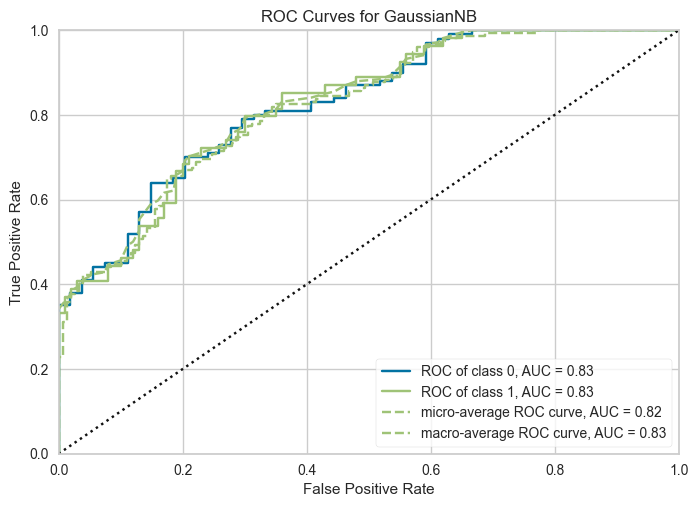

In [10]:
plot_model(best,plot='auc')

In [11]:
xgb_tuned = tune_model(best,search_library="optuna")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7742,0.8352,0.6818,0.6818,0.6818,0.5068,0.5068
1,0.6935,0.7591,0.6818,0.5556,0.6122,0.3632,0.3685
2,0.7097,0.7920,0.8182,0.5625,0.6667,0.4247,0.4482
3,0.7742,0.8523,0.7273,0.6667,0.6957,0.5167,0.5179
4,0.7705,0.8429,0.7619,0.6400,0.6957,0.5137,0.5187
5,0.8033,0.8405,0.6190,0.7647,0.6842,0.5436,0.5500
6,0.7049,0.8250,0.6667,0.5600,0.6087,0.3747,0.3784
7,0.7049,0.7952,0.5714,0.5714,0.5714,0.3464,0.3464
8,0.7377,0.7643,0.6667,0.6087,0.6364,0.4319,0.4330


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [12]:
#Optimize threshold
optimized_best = optimize_threshold(best)
print(optimized_best)

Threshold: 0.375. Accuracy: 0.7297
Threshold: 0.125. Accuracy: 0.596
Threshold: 0.5. Accuracy: 0.7426
Threshold: 0.25. Accuracy: 0.6922
Threshold: 0.625. Accuracy: 0.7507
Threshold: 0.75. Accuracy: 0.7378
Threshold: 0.875. Accuracy: 0.728
Threshold: 0.0. Accuracy: 0.3485
Threshold: 0.625. Accuracy: 0.7411
Threshold: 0.6250000149011612. Accuracy: 0.7524
Threshold: 0.21875. Accuracy: 0.6888
Threshold: 0.09375. Accuracy: 0.5505
Threshold: 0.3125. Accuracy: 0.7183
Threshold: 0.1875. Accuracy: 0.6661
Threshold: 0.34375. Accuracy: 0.7118
Threshold: 0.4375. Accuracy: 0.7312
Threshold: 0.46875. Accuracy: 0.7328
Threshold: 0.5625. Accuracy: 0.7442
Threshold: 0.59375. Accuracy: 0.7459
Threshold: 0.6875. Accuracy: 0.7475
Threshold: 0.71875. Accuracy: 0.754
Threshold: 0.8125. Accuracy: 0.7393
Threshold: 0.84375. Accuracy: 0.7361
Threshold: 0.9375. Accuracy: 0.7004
Threshold: 0.0625. Accuracy: 0.5032
Threshold: 0.96875. Accuracy: 0.6923
Threshold: 0.3125. Accuracy: 0.7117
Threshold: 0.3125000149011

CustomProbabilityThresholdClassifier(classifier=GaussianNB(priors=None,
                                                           var_smoothing=1e-09),
                                     priors=None,
                                     probability_threshold=0.7180480952674759,
                                     var_smoothing=1e-09)


In [13]:
new = create_model('knn',probability_threshold=0.6868)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,17:04:11
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7742,0.8392,0.5000,0.7857,0.6111,0.4629,0.4863
1,0.7097,0.7136,0.5909,0.5909,0.5909,0.3659,0.3659
2,0.7581,0.8352,0.5909,0.6842,0.6341,0.4549,0.4576
3,0.7258,0.8045,0.5909,0.6190,0.6047,0.3949,0.3952
4,0.7213,0.6744,0.5238,0.6111,0.5641,0.3611,0.3634
5,0.8033,0.7940,0.5714,0.8000,0.6667,0.5326,0.5477
6,0.8197,0.8345,0.6667,0.7778,0.7179,0.5866,0.5903
7,0.6066,0.6625,0.2857,0.4000,0.3333,0.0651,0.0670
8,0.7049,0.7607,0.5238,0.5789,0.5500,0.3313,0.3322


In [14]:
save_model(new,'best_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Pregnancies', 'Glucose',
                                              'BloodPressure', 'SkinThickness',
                                              'Insulin', 'BMI',
                                              'DiabetesPedigreeFunction',
                                              'Age'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 (...
          

In [15]:
import pickle
pickle.dump(new,open('new_model.pkl','wb'))